In [1]:
include("../src/main.jl");

In [2]:
dump_filepath = "../src/models/iharm3dDumps/dump_001.h5";

In [3]:
#TODO: put this in reading file
N1 = 128
N2 = 64
N3 = 32

trat_large = 20. #TODO: prob have to be read from file
trat_small = 1. #TODO: prob have to be read from file
beta_crit = 1.0 #TODO: prob have to be read from file
game = (4. /3.)  # Ion adiabatic index  TODO: prob have to be read from file
gamp = (5. /3.)  # Electron adiabatic index TODO: prob have to be read from file
gam = (13. /9.)  # Total adiabatic index TODO: prob have to be read from file
Ne_factor = 1.0  # Scaling factor for electron number density TODO: prob have to be read from file
sigma_cut = 1.0 #TODO: maybe put it somewhere else?
sigma_cut_high = -1.0
startx::MVec4 = [0, 1.874000951149813e-03, 0, 0]#TODO: prob have to be read from file
stopx::MVec4 = [1, 6.907755278982138e+00, 1, 2 * π]#TODO: prob have to be read from file
dx::MVec4 = [0, 5.395219748461709e-02, 1.562500000000000e-02, 1.963495408493621e-01] #TODO: prob have to be read from file
bhspin = 0.9375 #TODO: prob have to be read from file
hslope = 0.3 #TODO: prob have to be read from file
simulation_data = load_data(dump_filepath);

Loading data from '../src/models/iharm3dDumps/dump_001.h5' into 'iharm' module...
Using mixed tp_over_te with trat_small = 1.0, trat_large = 20.0, and beta_crit = 1.0
data_array: 870.0546975445741
B_unit: 66.4216771242051
All primitives successfully loaded. Dimensions: (128, 64, 32)


In [8]:
#Analytic parameters

#Setting up the parameters
#Observer distance in Rg
ro = 1000.0
#Observer inclination in degrees
th = 17.0

#Observer azimuth in degrees
phi = 0.0

# Size of the screen in Rg in both directions
DXsize = 160.0
DYsize = 160.0

# Observer fov in radians (this can be understood as size of the plane camera sees over the distance ro)
# This should be atan, but for small angles it is approximately equal to the angle itself
fovx = DXsize/ro
fovy = DYsize/ro

# Number of pixels in the x and y direction. The number of geodesics calculated will be res^2
res = 40
pixels_x = 40
pixels_y = 40
# Distance to the source in parsecs
SourceD = 7.778e3 * PC
Rout = 1000.0
Rstop = 10000.0
Rh = 1 + sqrt(1. - bhspin * bhspin);


#Check if these are correct
cstartx = [0.0, log(Rh), 0.0, 0.0]#TODO: prob have to be read from file
cstopx = [0.0, log(1000.0), 1.0, 2.0 * π]#TODO: prob have to be read from file

# Frequency observed by the camera in Hz
freq = 230e9;


In [9]:
include("../src/main.jl");
# Find camera in native coordinates
Xcamera = MVec4(camera_position(ro, th, phi, bhspin, Rout))

# Scales the intensity of each pixel by the real size of each pixel
scale_factor = CalculateScaleFactor(DXsize, DYsize, pixels_x, pixels_y, SourceD, L_unit)

maxnstep = 15000
# Generate geodesics
println("Utilizing $(Threads.nthreads()) threads for geodesic calculation.")
freq_unitless = freq * HPL/(ME * CL * CL)  # Convert frequency to unitless
Image = zeros(Float64, pixels_x, pixels_y)
for i in 0:(pixels_x - 1)
    println("Processing row $i out of $(pixels_x)")

    Threads.@threads for j in 0:(pixels_y - 1)
        traj = Vector{OfTraj}()
        sizehint!(traj, maxnstep)

        nstep = get_pixel(traj, i, j, Xcamera, maxnstep, fovx, fovy, freq_unitless, pixels_x, pixels_y, bhspin, Rh, Rout, Rstop)

        resize!(traj, length(traj))
        integrate_emission!(traj, length(traj), Image, i + 1, j + 1, freq, bhspin, simulation_data)

    end
end
Image *= freq^3;

Utilizing 12 threads for geodesic calculation.


Processing row 0 out of 40
Processing row 1 out of 40
Processing row 2 out of 40
Processing row 3 out of 40
Processing row 4 out of 40
Processing row 5 out of 40
Processing row 6 out of 40
Processing row 7 out of 40
Processing row 8 out of 40
Processing row 9 out of 40
Processing row 10 out of 40
Processing row 11 out of 40
Processing row 12 out of 40
Processing row 13 out of 40
Processing row 14 out of 40
Processing row 15 out of 40
Processing row 16 out of 40
Processing row 17 out of 40
Processing row 18 out of 40
Processing row 19 out of 40
Processing row 20 out of 40
Processing row 21 out of 40
Processing row 22 out of 40
Processing row 23 out of 40
Processing row 24 out of 40
Processing row 25 out of 40
Processing row 26 out of 40
Processing row 27 out of 40
Processing row 28 out of 40
Processing row 29 out of 40
Processing row 30 out of 40
Processing row 31 out of 40
Processing row 32 out of 40
Processing row 33 out of 40
Processing row 34 out of 40
Processing row 35 out of 40
Pr

In [10]:
OutputStokesParameters(Image, freq, scale_factor, res, SourceD)

Image processing complete. Calculating total flux and averages...
Scale = 2.329439650873966e+09
imax = 40, jmax = 40, Imax = 0.0002892453301806385, Iavg = 0.00011254594486400224
Using freq_cgs = 2.3e11, Ftot = 4.1947037841805154e8
nuLnu = 6.983547376454848e42


In [ ]:
using CairoMakie
using Printf

d_kpc = 7.78
d_cm = d_kpc * 3.086e21           # distance in cm
fov_rg = 30                       # field of view in gravitational radii
half_fov_rg = fov_rg / 2

# Angular resolution
theta_rad = (half_fov_rg * L_unit) / d_cm   # half FOV in radians
theta_μas = theta_rad * MUAS_PER_RAD        # convert to μas
xlims = (-theta_μas, theta_μas)
ylims = (-theta_μas, theta_μas)

# Generate mock image (or load your 128x128 array here)
img = Image

# Axes
Ny, Nx = size(img)
x = range(xlims[1], xlims[2], length=Nx)
y = range(ylims[1], ylims[2], length=Ny)

# Plot
fig = Figure(size = (600, 500))
ax = Axis(fig[1, 1],
    xlabel = "Relative R.A [μas]",
    ylabel = "Relative Dec [μas]",
    xlabelsize=24,
    ylabelsize=24,
    xticklabelsize=20,
    yticklabelsize=20,
    limits = (xlims, ylims)
)

# Heatmap with color range
crange = extrema(img)
hm = heatmap!(ax, x, y, img; colormap=:hot, colorrange=crange)

# Colorbar
Colorbar(fig[1, 2], hm;
    label = "Intensity",
    labelsize = 20,
    ticklabelsize = 16,
    width = 15
)

fig


In [1]:
# From Ipole

In [1]:
using HDF5

function load_ipole_unpol(fname)
    hfp = h5open(fname, "r") do file
        # Read values
        dx = read(file["header/camera/dx"])
        dsource = read(file["header/dsource"])
        lunit = read(file["header/units/L_unit"])
        scale = read(file["header/scale"])

        fov_muas = dx / dsource * lunit * 2.06265e11

        # evpa_0 might not exist
        evpa_0 = haskey(file["header"], "evpa_0") ? read(file["header/evpa_0"]) : "W"

        # Load and transpose unpol
        unpol = read(file["unpol"])
        unpol_t = permutedims(unpol, (2,1))

        return unpol_t, fov_muas, scale, evpa_0
    end

    return hfp
end

load_ipole_unpol (generic function with 1 method)

In [2]:
Image1, _, _, _= load_ipole_unpol("../../ipole/image.h5")

([0.0028500540023181876 0.002210882226610331 … 0.0027371326435186656 0.00276842273565713; 0.002867193977126099 0.002251569832406245 … 0.0025676325949308704 0.0027217056400040134; … ; 0.004478895524290718 0.004620423867986511 … 0.001640696744011861 0.0017108453493655305; 0.004409480881611284 0.004470648254926924 … 0.0016692957552302326 0.0017161996865154932], 30.0, 1.3221217339778846, "N")

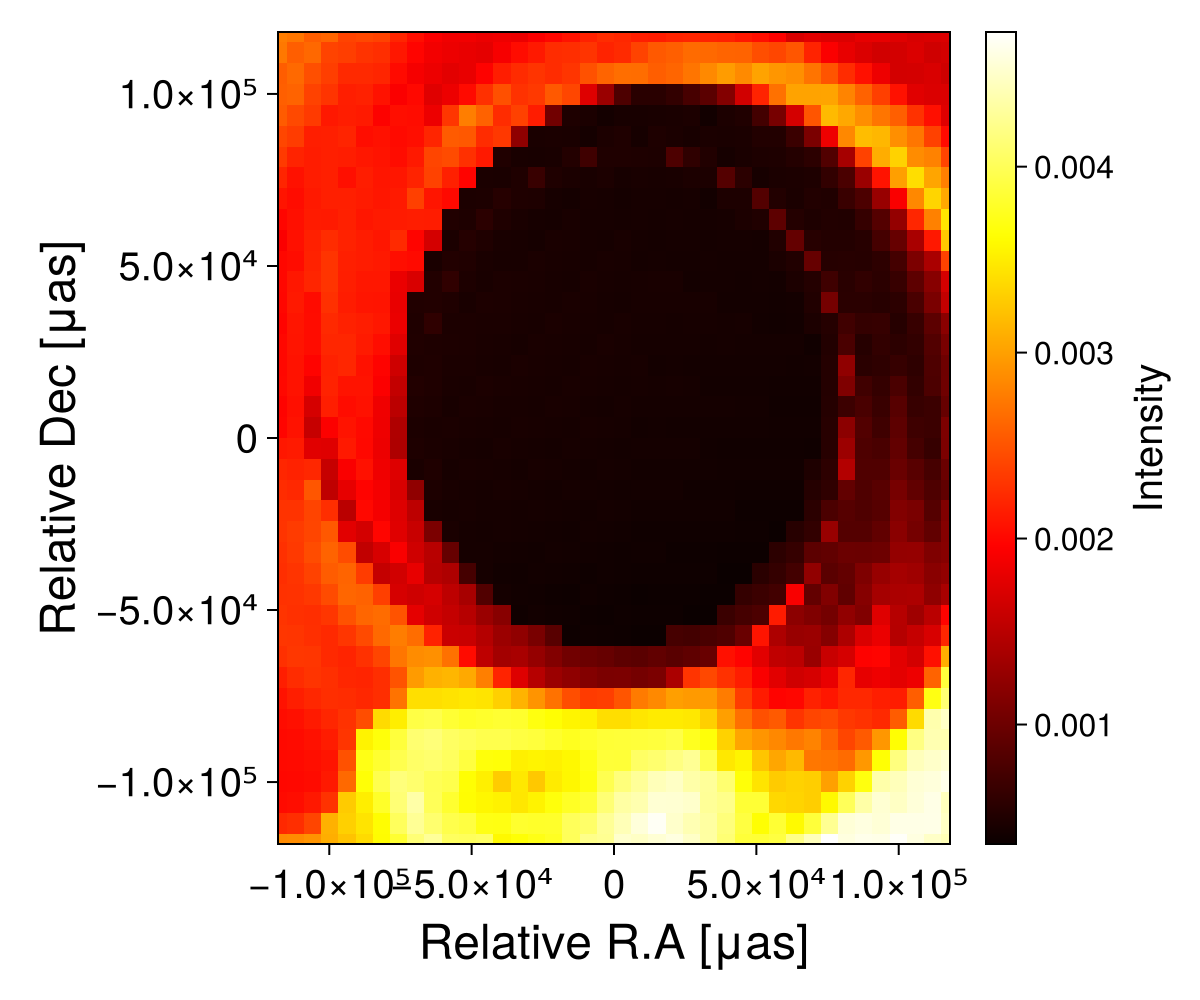

In [8]:
using CairoMakie
using Printf

d_kpc = 7.78
d_cm = d_kpc * 3.086e21           # distance in cm
fov_rg = 30                       # field of view in gravitational radii
half_fov_rg = fov_rg / 2

# Angular resolution
theta_rad = (half_fov_rg * L_unit) / d_cm   # half FOV in radians
theta_μas = theta_rad * MUAS_PER_RAD        # convert to μas
xlims = (-theta_μas, theta_μas)
ylims = (-theta_μas, theta_μas)

# Generate mock image (or load your 128x128 array here)
img = Image1

# Axes
Ny, Nx = size(img)
x = range(xlims[1], xlims[2], length=Nx)
y = range(ylims[1], ylims[2], length=Ny)

# Plot
fig = Figure(size = (600, 500))
ax = Axis(fig[1, 1],
    xlabel = "Relative R.A [μas]",
    ylabel = "Relative Dec [μas]",
    xlabelsize=24,
    ylabelsize=24,
    xticklabelsize=20,
    yticklabelsize=20,
    limits = (xlims, ylims)
)

# Heatmap with color range
crange = extrema(img)
hm = heatmap!(ax, x, y, img; colormap=:hot, colorrange=crange)

# Colorbar
Colorbar(fig[1, 2], hm;
    label = "Intensity",
    labelsize = 20,
    ticklabelsize = 16,
    width = 15
)

fig
